# Cardio HSIC results: symbolic probability of ischemia

Reads the artefacts written by `cardio_hsic.ipynb` -- it does **not** retrain anything.
Run the training notebook first.

The KAAM symbolic model gives a closed-form expression for each mechanism. Because
`ischemia` is a discrete node, `kan_model_mixed` trains it as a classifier, so its formula
is a **logit**: the probability is recovered as `P(ischemia) = sigma(formula)`.

Since a KAAM is additive in its inputs, that logit splits into one term per parent plus a
constant. That decomposition is what both plots below are built from.

In [41]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from tueplots import bundles

from datasets.cardio import get_cardio_graph
from plotting.cardio_formula import get_delta, radar_factory
from utils.paths import get_experiment_paths

# Point this at another tree only if the training notebook wrote somewhere else.
OUTPUT_DIR = None
paths = get_experiment_paths('cardio', output_dir=OUTPUT_DIR)
data_dir, samples_dir = str(paths.data), str(paths.samples)

graph_cardio = get_cardio_graph()
factual_eval_d = pd.read_csv(os.path.join(data_dir, 'cardio_factual_eval_d.csv'))
with open(os.path.join(data_dir, 'cardio_node_info.pkl'), 'rb') as f:
    node_info = pickle.load(f)

TARGET = 'ischemia'
# Same ordering kan_model_mixed uses for a node's inputs, so formula symbols x_1..x_n line up.
x_cols = list(graph_cardio.predecessors(TARGET))

print(f'Evaluation set : {factual_eval_d.shape}')
print(f'Target         : {TARGET}')
print(f'Parents        : {x_cols}')
print(f'Parent types   : { {c: node_info[c]["type"] for c in x_cols} }')

Evaluation set : (10, 6)
Target         : ischemia
Parents        : ['age', 'bmi', 'systolic', 'diabetes']
Parent types   : {'age': 'continuous', 'bmi': 'continuous', 'systolic': 'continuous', 'diabetes': 'discrete'}


## The symbolic mechanism for ischemia

In [42]:
with open(os.path.join(samples_dir, 'cardio_formulas_kaam.pkl'), 'rb') as f:
    formulae = pickle.load(f)

# get_delta renames the generic x_1..x_n symbols to the actual parent names.
formula_logit, delta_frames = get_delta(factual_eval_d[x_cols], formulae[TARGET])
delta = delta_frames[0]
const = float(delta['const'].iloc[0])

used = sorted((str(s) for s in formula_logit.free_symbols), key=x_cols.index)
dropped = [c for c in x_cols if c not in used]

# get_delta only emits columns for parents that survive pruning; reinstate the rest as zeros
# so every parent has a (possibly flat) contribution to plot.
delta_terms = delta.drop(columns='const').reindex(columns=x_cols, fill_value=0.0)

print('logit P(ischemia) =')
print(f'  {sp.expand(formula_logit)}\n')
print('P(ischemia) =')
print(f'  sigma({sp.expand(formula_logit)})\n')

print(f'Parents in the formula : {used}')
print(f'Pruned away            : {dropped if dropped else "none"}')
print(f'Constant term          : {const:.4f}')

# The additive split must reproduce the formula exactly, on however many patients the split has.
check = delta_terms.sum(axis=1) + const
direct = np.array([
    float(formula_logit.subs({sp.symbols(c): factual_eval_d[c].iloc[i] for c in used}))
    for i in range(len(factual_eval_d))
])
assert np.allclose(check.to_numpy(), direct, atol=1e-6), 'additive decomposition does not match the formula'
print(f'\nAdditive decomposition verified against the formula ({len(factual_eval_d)} patients).')

sp.Eq(sp.Symbol('P_ischemia'), sp.Function('sigma')(sp.expand(formula_logit)))

logit P(ischemia) =
  0.034*age + 0.009*bmi**2 - 0.003*bmi + 0.055*systolic**2 + 0.134*systolic + 0.069

P(ischemia) =
  sigma(0.034*age + 0.009*bmi**2 - 0.003*bmi + 0.055*systolic**2 + 0.134*systolic + 0.069)

Parents in the formula : ['age', 'bmi', 'systolic']
Pruned away            : ['diabetes']
Constant term          : 0.0690

Additive decomposition verified against the formula (10 patients).


Eq(P_ischemia, sigma(0.034*age + 0.009*bmi**2 - 0.003*bmi + 0.055*systolic**2 + 0.134*systolic + 0.069))

In [43]:
# Beta=0.0 reference: same symbolic decomposition, but for the model trained without the
# HSIC term (beta held at 0 for every node, instead of the value chosen by the sweep above).
with open(os.path.join(samples_dir, 'cardio_formulas_kaam_beta0.pkl'), 'rb') as f:
    formulae_beta0 = pickle.load(f)

formula_logit_beta0, delta_frames_beta0 = get_delta(factual_eval_d[x_cols], formulae_beta0[TARGET])
delta_beta0 = delta_frames_beta0[0]
const_beta0 = float(delta_beta0['const'].iloc[0])

used_beta0 = sorted((str(s) for s in formula_logit_beta0.free_symbols), key=x_cols.index)
dropped_beta0 = [c for c in x_cols if c not in used_beta0]
delta_terms_beta0 = delta_beta0.drop(columns='const').reindex(columns=x_cols, fill_value=0.0)

print('logit P(ischemia) [beta=0] =')
print(f'  {sp.expand(formula_logit_beta0)}\n')
print(f'Parents in the formula : {used_beta0}')
print(f'Pruned away            : {dropped_beta0 if dropped_beta0 else "none"}')
print(f'Constant term          : {const_beta0:.4f}')

logit P(ischemia) [beta=0] =
  0.034*age + 0.009*bmi**2 - 0.003*bmi + 0.055*systolic**2 + 0.134*systolic + 0.069

Parents in the formula : ['age', 'bmi', 'systolic']
Pruned away            : ['diabetes']
Constant term          : 0.0690


## Partial dependence of P(ischemia) on each parent

For parent `j` swept over its observed range, the other parents are held at their mean
contribution across the evaluation set:

`P(ischemia | x_j = v) = sigma(const + sum_{k != j} mean(delta_k) + delta_j(v))`

Continuous axes are shown in original clinical units; `diabetes` is binary, so it gets two
points rather than a curve. Each panel overlays the optimal-beta model against the beta=0
reference (no HSIC term).

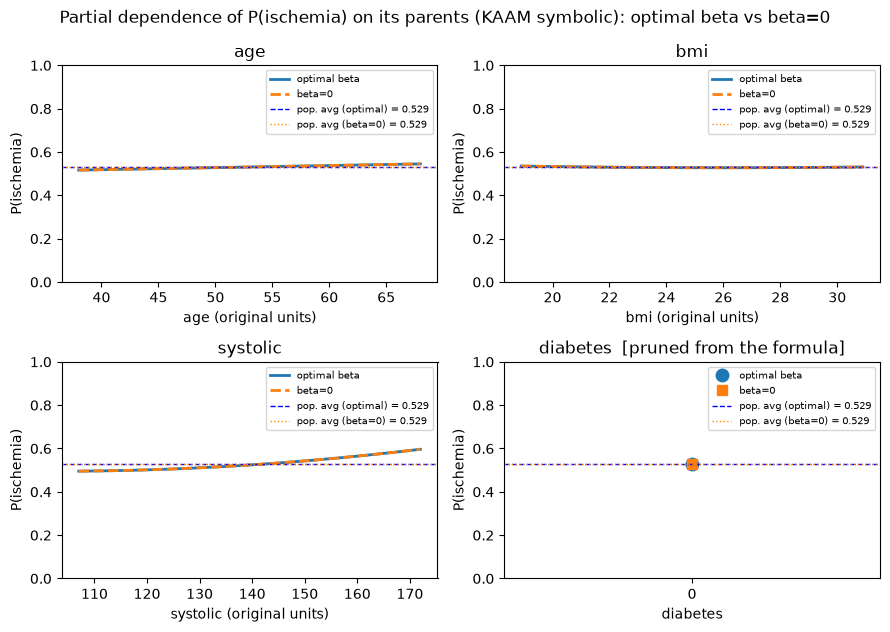

Saved -> C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures\ischemia_pdp.pdf
NOTE: the beta=0 and optimal-beta ischemia mechanisms are identical, so the curves coincide.


In [44]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def term_values(var, grid_values, formula, used_vars):
    """Evaluate this parent's additive contribution over a grid, in standardised units."""
    if var not in used_vars:
        return np.zeros_like(grid_values, dtype=float)
    dependent_part = formula.as_independent(sp.symbols(var), as_Add=True)[1]
    single = sp.lambdify(sp.symbols(var), dependent_part, 'numpy')
    return np.asarray(single(grid_values), dtype=float) * np.ones_like(grid_values, dtype=float)


def denorm(var, values):
    if node_info[var]['type'] != 'continuous':
        return values
    return values * node_info[var]['std'] + node_info[var]['mean']


mean_delta = delta_terms.mean(axis=0)
baseline = const + mean_delta.sum()

mean_delta_beta0 = delta_terms_beta0.mean(axis=0)
baseline_beta0 = const_beta0 + mean_delta_beta0.sum()

n_cols = 2
n_rows = int(np.ceil(len(x_cols) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(9, 3.2 * n_rows), squeeze=False)

for i, var in enumerate(x_cols):
    ax = axs[i // n_cols][i % n_cols]
    observed = factual_eval_d[var].to_numpy()
    is_continuous = node_info[var]['type'] == 'continuous'

    if is_continuous:
        grid = np.linspace(observed.min(), observed.max(), 200)
    else:
        grid = np.array(sorted(np.unique(observed)), dtype=float)

    # Swap this parent's mean contribution for its value on the grid.
    prob = sigmoid(baseline - mean_delta[var] + term_values(var, grid, formula_logit, used))
    prob_beta0 = sigmoid(baseline_beta0 - mean_delta_beta0[var]
                         + term_values(var, grid, formula_logit_beta0, used_beta0))
    x_plot = denorm(var, grid)

    if is_continuous:
        ax.plot(x_plot, prob, color='tab:blue', lw=2, label='optimal beta')
        ax.plot(x_plot, prob_beta0, color='tab:orange', lw=2, ls='--', label='beta=0')
    else:
        # Markers only: a binary parent has no intermediate values to interpolate through.
        ax.plot(x_plot, prob, 'o', color='tab:blue', ms=9, label='optimal beta')
        ax.plot(x_plot, prob_beta0, 's', color='tab:orange', ms=7, label='beta=0')
        ax.set_xticks(x_plot)
        ax.set_xlim(x_plot.min() - 0.3, x_plot.max() + 0.3)

    ax.axhline(sigmoid(baseline), color='b', ls='--', lw=1,
               label=f'pop. avg (optimal) = {sigmoid(baseline):.3f}')
    ax.axhline(sigmoid(baseline_beta0), color='darkorange', ls=':', lw=1,
               label=f'pop. avg (beta=0) = {sigmoid(baseline_beta0):.3f}')
    ax.set_xlabel(f"{var}{' (original units)' if is_continuous else ''}")
    ax.set_ylabel('P(ischemia)')
    ax.set_ylim(0, 1)
    ax.set_title(f'{var}' + ('' if var in used else '  [pruned from the formula]'))
    ax.legend(fontsize=7)
    assert np.all((prob >= 0) & (prob <= 1)), f'{var}: probabilities left [0, 1]'
    assert np.all((prob_beta0 >= 0) & (prob_beta0 <= 1)), f'{var}: beta=0 probabilities left [0, 1]'

for j in range(len(x_cols), n_rows * n_cols):
    axs[j // n_cols][j % n_cols].axis('off')

fig.suptitle('Partial dependence of P(ischemia) on its parents (KAAM symbolic): optimal beta vs beta=0')
fig.tight_layout()
fig.savefig(paths.figures / 'ischemia_pdp.pdf', bbox_inches='tight')
plt.show()
print(f"Saved -> {paths.figures / 'ischemia_pdp.pdf'}")

# ischemia is a discrete node, so kan_model_mixed trains it with cross-entropy and beta is inert:
# expect the two curves to coincide exactly unless that changes.
if np.allclose(delta_terms.to_numpy(), delta_terms_beta0.to_numpy(), atol=1e-9) and np.isclose(const, const_beta0):
    print('NOTE: the beta=0 and optimal-beta ischemia mechanisms are identical, so the curves coincide.')

## Partial dependence of P(ischemia) on each parent -- beta=0 reference

Same construction as above, but for the KAAM model trained with beta=0 for every node (no
HSIC term) -- the option excluded from the beta search. Shown as a baseline to see what the
HSIC penalty changes mechanism-wise.

## Companion view: each parent's contribution to the logit

The same decomposition on the logit scale, where the KAAM is additive and the per-parent
curves are exactly the symbolic terms. Follows the layout of `notebooks/alejandro/cardio.ipynb`.
Each panel overlays the optimal-beta model against the beta=0 reference (no HSIC term).

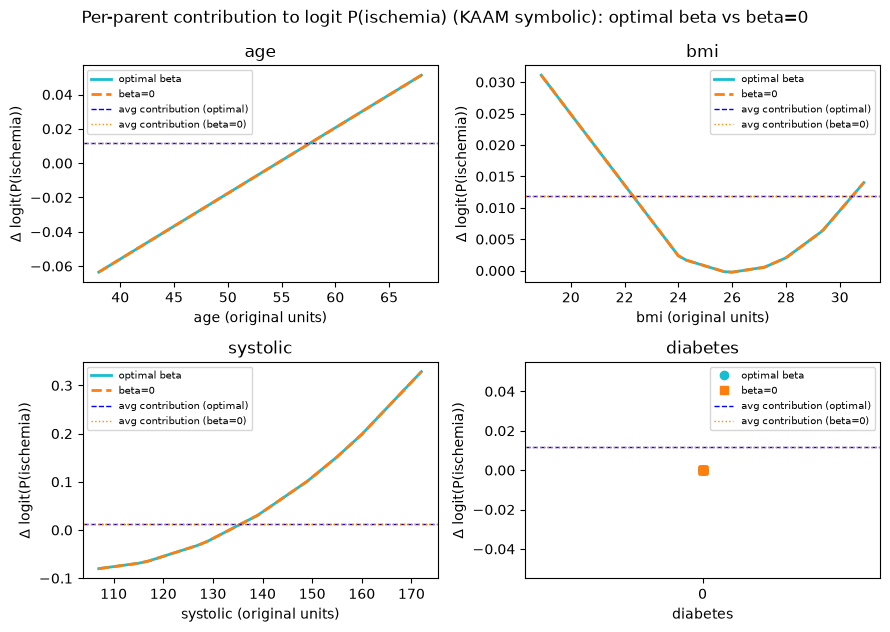

Saved -> C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures\ischemia_pdp_logit.pdf

Mean contribution per parent (logit scale) - optimal beta:
age        -0.0134
bmi         0.0064
systolic    0.0542
diabetes    0.0000
constant: 0.0690
baseline P(ischemia) at mean contributions: 0.5290

Mean contribution per parent (logit scale) - beta=0:
age        -0.0134
bmi         0.0064
systolic    0.0542
diabetes    0.0000
constant: 0.0690
baseline P(ischemia) at mean contributions: 0.5290

observed P(ischemia) in the evaluation set: 0.3000


In [45]:
fig, axs = plt.subplots(n_rows, n_cols, figsize=(9, 3.2 * n_rows), squeeze=False)
avg_line = float(mean_delta.mean())
avg_line_beta0 = float(mean_delta_beta0.mean())

for i, var in enumerate(x_cols):
    ax = axs[i // n_cols][i % n_cols]
    order = np.argsort(factual_eval_d[var].to_numpy())
    x_plot = denorm(var, factual_eval_d[var].to_numpy()[order])
    y_plot = delta_terms[var].to_numpy()[order]
    y_plot_beta0 = delta_terms_beta0[var].to_numpy()[order]

    if node_info[var]['type'] == 'continuous':
        ax.plot(x_plot, y_plot, color='tab:cyan', lw=2, label='optimal beta')
        ax.plot(x_plot, y_plot_beta0, color='tab:orange', lw=2, ls='--', label='beta=0')
    else:
        ax.plot(x_plot, y_plot, 'o', color='tab:cyan', ms=6, label='optimal beta')
        ax.plot(x_plot, y_plot_beta0, 's', color='tab:orange', ms=6, label='beta=0')
        ax.set_xticks(sorted(np.unique(x_plot)))

    ax.axhline(avg_line, color='b', ls='--', lw=1, label='avg contribution (optimal)')
    ax.axhline(avg_line_beta0, color='darkorange', ls=':', lw=1, label='avg contribution (beta=0)')
    ax.set_xlabel(f"{var}{'' if node_info[var]['type'] == 'discrete' else ' (original units)'}")
    ax.set_ylabel(r'$\Delta$ logit(P(ischemia))')
    ax.set_title(var)
    ax.legend(fontsize=7)

for j in range(len(x_cols), n_rows * n_cols):
    axs[j // n_cols][j % n_cols].axis('off')

fig.suptitle('Per-parent contribution to logit P(ischemia) (KAAM symbolic): optimal beta vs beta=0')
fig.tight_layout()
fig.savefig(paths.figures / 'ischemia_pdp_logit.pdf', bbox_inches='tight')
plt.show()
print(f"Saved -> {paths.figures / 'ischemia_pdp_logit.pdf'}")

print('\nMean contribution per parent (logit scale) - optimal beta:')
print(mean_delta.round(4).to_string())
print(f'constant: {const:.4f}')
print(f'baseline P(ischemia) at mean contributions: {sigmoid(baseline):.4f}')

print('\nMean contribution per parent (logit scale) - beta=0:')
print(mean_delta_beta0.round(4).to_string())
print(f'constant: {const_beta0:.4f}')
print(f'baseline P(ischemia) at mean contributions: {sigmoid(baseline_beta0):.4f}')

print(f'\nobserved P(ischemia) in the evaluation set: {factual_eval_d[TARGET].mean():.4f}')

## Radar plot: two random individuals against the population average

Same construction as the radar in `notebooks/alejandro/cardio.ipynb`. Each spoke is one
parent of `ischemia`. Along spoke `j` we plot the individual's risk when **only** parent `j`
takes that person's value and every other parent stays at its mean contribution:

`P_j = sigma(const + delta_j(x_j) + sum_{k != j} mean(delta_k))`

so the dashed blue polygon (everyone at the mean) is the reference and a spoke pushed
outwards means that parent raises this person's risk above the population average.

The radial axis is zoomed to the range of the plotted values -- anchored at 0 the three
polygons sit on top of each other.

C:\Users\aarna\AppData\Local\Temp\ipykernel_29112\2279913651.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.8, 1])


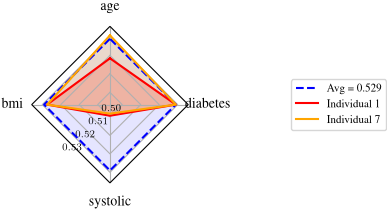

Saved -> C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures\ischemia_radar.pdf
Population average P(ischemia) = 0.5290

Individual 1: {'age': 40.0, 'bmi': 25.7, 'systolic': 117.0, 'diabetes': 0.0}
  per-spoke P(ischemia)     : {'age': 0.5184, 'bmi': 0.5274, 'systolic': 0.4994, 'diabetes': 0.529}
  all parents at own values : 0.4871
  observed ischemia         : 0
Individual 7: {'age': 53.0, 'bmi': 26.0, 'systolic': 115.0, 'diabetes': 0.0}
  per-spoke P(ischemia)     : {'age': 0.5308, 'bmi': 0.5274, 'systolic': 0.4983, 'diabetes': 0.529}
  all parents at own values : 0.4984
  observed ischemia         : 0


In [46]:
PATIENT_SEED = 2026
rng = np.random.default_rng(PATIENT_SEED)
patient_ids = rng.choice(len(factual_eval_d), size=2, replace=False)

n_feats = len(x_cols)
theta = radar_factory(n_feats, frame='polygon')
colors = ['r', 'orange']

avg_ring = sigmoid(baseline) * np.ones(n_feats)
# Row j of this matrix is "everyone at the mean"; overwriting its diagonal entry swaps in
# the individual's own contribution for parent j only.
avg_matrix = np.repeat(mean_delta.to_numpy()[None, :], n_feats, axis=0)

curves = {}
for patient_id in patient_ids:
    matrix = avg_matrix.copy()
    np.fill_diagonal(matrix, delta_terms.iloc[patient_id].to_numpy())
    curves[patient_id] = sigmoid(matrix.sum(axis=1) + const)

all_values = np.concatenate([avg_ring, *curves.values()])
pad = 0.15 * (all_values.max() - all_values.min() + 1e-9)

with plt.rc_context({**bundles.iclr2024()}):
    fig, ax = plt.subplots(subplot_kw=dict(projection='radar'), figsize=(5, 3))

    ax.plot(theta, avg_ring, label=f'Avg = {sigmoid(baseline):.3f}', color='b', linestyle='--')
    ax.fill(theta, avg_ring, alpha=0.1, color='b')

    for j, patient_id in enumerate(patient_ids):
        ax.plot(theta, curves[patient_id], label=f'Individual {patient_id}', color=colors[j])
        ax.fill(theta, curves[patient_id], alpha=0.2, color=colors[j])

    ax.set_ylim(all_values.min() - pad, all_values.max() + pad)
    ax.set_rlabel_position(135)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_varlabels(x_cols, fontsize=10)
    ax.legend(loc='center right', bbox_to_anchor=(2.3, 0.5), ncol=1, fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.savefig(paths.figures / 'ischemia_radar.pdf', bbox_inches='tight')
    plt.show()

print(f"Saved -> {paths.figures / 'ischemia_radar.pdf'}")
print(f'Population average P(ischemia) = {sigmoid(baseline):.4f}\n')
for patient_id in patient_ids:
    raw = {c: round(float(denorm(c, factual_eval_d[c].iloc[patient_id])), 2) for c in x_cols}
    spokes = {c: round(float(v), 4) for c, v in zip(x_cols, curves[patient_id])}
    full = sigmoid(delta_terms.iloc[patient_id].sum() + const)
    print(f'Individual {patient_id}: {raw}')
    print(f'  per-spoke P(ischemia)     : {spokes}')
    print(f'  all parents at own values : {full:.4f}')
    print(f'  observed {TARGET}         : {int(factual_eval_d[TARGET].iloc[patient_id])}')